In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import sys
import seaborn as sns

## Подготовка данных

In [2]:
# Загрузка и предварительная очистка
url = f"https://raw.githubusercontent.com/kirieshka2005/Data-Science-Projects/refs/heads/main/data/BostonHousing.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.shape

(506, 14)

In [5]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
df_cleaned = df.dropna()
df_cleaned = df_cleaned.drop(columns= df_cleaned.columns[0]) # удалили строку с индексами

In [7]:
df_cleaned.shape

(506, 13)

In [8]:
# === Таблица с описанием признаков (вручную, так как файл не содержит метаданных) ===
feature_description = pd.DataFrame({
    'Признак': [
        'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
        'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
    ],
    'Описание': [
        'Уровень преступности на душу населения по городам',
        'Доля земли под жилую застройку (>25 000 кв. футов)',
        'Доля не розничной торговли в акрах на город',
        'Граничит ли участок с рекой? (1 = да, 0 = нет)',
        'Концентрация оксидов азота (частей на 10 млн)',
        'Среднее число комнат в жилище',
        'Доля домов, построенных до 1940 года',
        'Взвешенное расстояние до пяти бостонских центров занятости',
        'Индекс доступности радиальных магистралей',
        'Полная ставка налога на имущество (на $10,000)',
        'Соотношение учеников к учителям по городу',
        '1000(Bk - 0.63)², где Bk — доля чернокожих по городу',
        '% населения с низким социальным статусом',
        'Медианная стоимость домов, занимаемых владельцами, в тысячах долларов США (например, 20 = $20,000)'
    ]
})

# Отображение таблиц в ноутбуке
print("Признаки датасета Boston:")
display(feature_description)

Признаки датасета Boston:


,Признак,Описание
0,CRIM,Уровень преступности на душу населения по городам
1,ZN,Доля земли под жилую застройку (>25 000 кв. фу...
2,INDUS,Доля не розничной торговли в акрах на город
3,CHAS,"Граничит ли участок с рекой? (1 = да, 0 = нет)"
4,NOX,Концентрация оксидов азота (частей на 10 млн)
5,RM,Среднее число комнат в жилище
6,AGE,"Доля домов, построенных до 1940 года"
7,DIS,Взвешенное расстояние до пяти бостонских центр...
8,RAD,Индекс доступности радиальных магистралей
9,TAX,"Полная ставка налога на имущество (на $10,000)"


<Axes: >

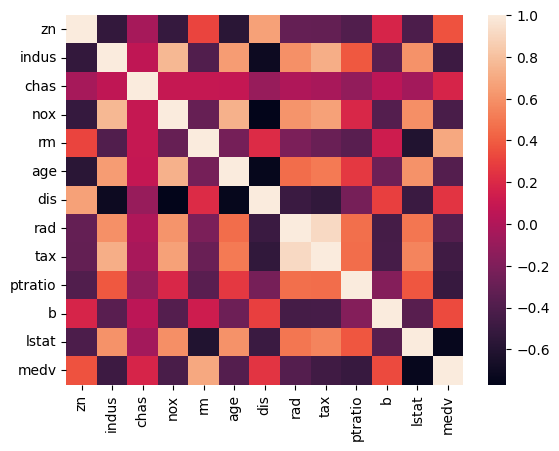

In [9]:
corr_matrix = df_cleaned.corr()
sns.heatmap(corr_matrix)

## Разделение на тестовую и обучающуюю выборку

In [10]:
# выделяем целевую переменную СНАЧАЛА
y = df_cleaned["medv"]

# удаляем целевую переменную из признаков, затем оставляем только числовые
X = df_cleaned.drop(columns=["medv"]).select_dtypes(include=[np.number])

# разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# масштабируем ТОЛЬКО после разделения
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)         

## Построение моделей

In [11]:
# 1. Линейная регрессия (на неотмасштабированных данных, но можно и на scaled — результат тот же)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [12]:
# 2. Lasso регрессия (требует масштабирования)
lasso = Lasso(alpha=1.0, random_state=42, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)


In [13]:
# 3. Ridge регрессия
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)


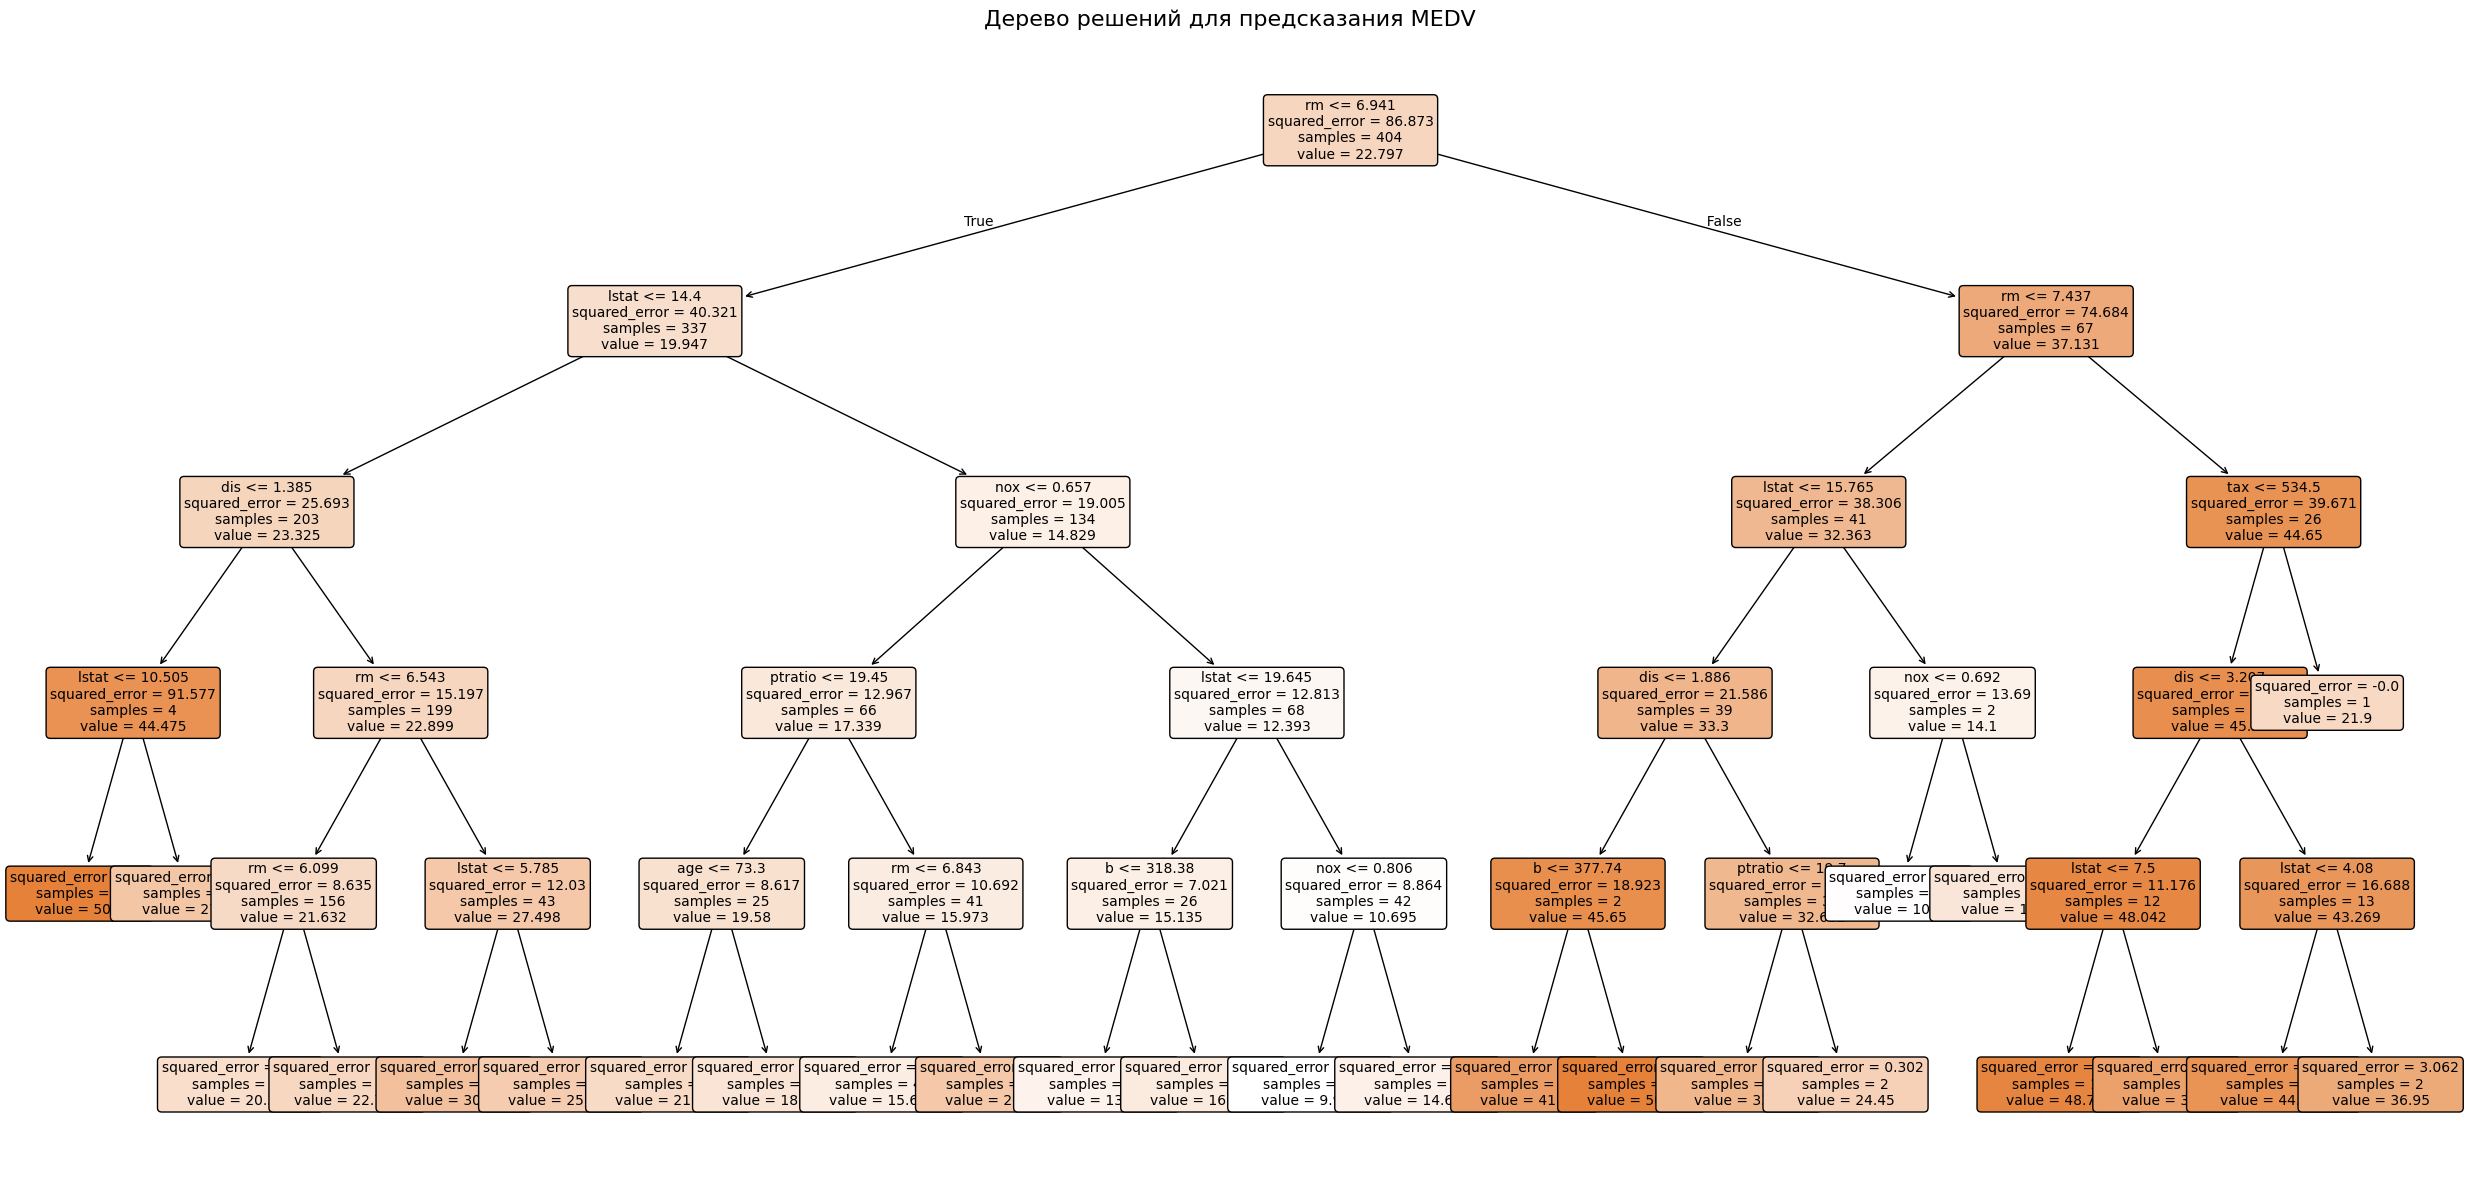

In [17]:
# 4. Дерево решений
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
# === Визуализация дерева решений ===
plt.figure(figsize=(25, 12))  # Большой размер для читаемости
plot_tree(
    dt_model,
    feature_names=X.columns,  # Имена признаков (включая закодированные)
    filled=True,              # Цвета узлов по доминирующему классу/среднему значению
    rounded=True,             # Закруглённые углы
    fontsize=10               # Размер шрифта
)
plt.title("Дерево решений для предсказания MEDV", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
# 5. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=40, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)


In [16]:
# === Вывод результатов ===
print('--- Линейная Регрессия ---')
print(f'MSE: {mse_lr:.2f}, R²: {r2_lr:.4f}')

print('\n--- Lasso Регрессия (alpha=1.0) ---')
print(f'MSE: {mse_lasso:.2f}, R²: {r2_lasso:.4f}')

print('\n--- Ridge Регрессия (alpha=1.0) ---')
print(f'MSE: {mse_ridge:.2f}, R²: {r2_ridge:.4f}')

print('\n--- Дерево Решений ---')
print(f'MSE: {mse_dt:.2f}, R²: {r2_dt:.4f}')

print('\n--- Random Forest ---')
print(f'MSE: {mse_rf:.2f}, R²: {r2_rf:.4f}')


--- Линейная Регрессия ---
MSE: 24.35, R²: 0.6680

--- Lasso Регрессия (alpha=1.0) ---
MSE: 27.57, R²: 0.6240

--- Ridge Регрессия (alpha=1.0) ---
MSE: 24.37, R²: 0.6677

--- Дерево Решений ---
MSE: 19.96, R²: 0.7278

--- Random Forest ---
MSE: 8.46, R²: 0.8846
